In [580]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import glob
import os

In [581]:
version = 9

In [582]:
ruta_busqueda = "datos_resultados/"
archivos_csv = glob.glob(f"{ruta_busqueda}/*v{version}*.csv")

In [583]:
ruta = './../ruta_datos/'
archivos = [ './../ruta_datos/' + f for f in os.listdir(ruta) if os.path.isfile(os.path.join(ruta, f))]

In [584]:
lista_dataframes = []
for i in archivos_csv:
    df_temp = pd.read_csv(i)
    df_temp['ruta'] = i
    df_temp['etapa'] = df_temp['ruta'].str.split('.').str[0].str.split('_').str[-1].astype(int)
    df_temp['archivo'] = df_temp['ruta'].str.split('.').str[0].str.split('_').str[-3]
    df_temp['etapa'] = df_temp['etapa']*10 + 1
    df_temp['etapa'] = df_temp['etapa'].astype(int)
    lista_dataframes.append(df_temp)
    del df_temp
df = pd.concat(lista_dataframes)

In [585]:
lista_dataframes = []
for i in archivos:
    df_temp = pd.read_csv(i)
    df_temp = df_temp.reset_index()
    df_temp = df_temp.rename(columns={'index':'ID'})
    df_temp['ruta'] = i
    df_temp['archivo'] = 'v'+df_temp['ruta'].str.split('.').str[-2].str.split('_').str[-1]
    lista_dataframes.append(df_temp)
    del df_temp
df2 = pd.concat(lista_dataframes)

In [586]:
df_test = df.groupby(['source_id','archivo']).agg({'ConteoAgrupaciones':['min','max','sum','mean','median']}).reset_index()
df_test.columns = ['source_id','archivo','min','max','sum','mean','median']
df_test.sort_values(by=['max'], ascending=[False])

,source_id,archivo,min,max,sum,mean,median
51619,5874184993646253952,v9,6,10,847,8.47,8.0
60612,5976590276800021760,v9,2,10,564,5.64,5.0
21897,4070924557563256704,v9,6,10,798,7.98,8.0
8398,2164360915284459008,v9,5,10,770,7.70,7.0
21888,4070817801870249856,v9,5,10,780,7.80,8.0
...,...,...,...,...,...,...,...
12454,4040137579230053248,v9,1,1,20,1.00,1.0
12453,4040136853414559616,v9,1,1,20,1.00,1.0
27166,4108453397704702464,v9,1,1,30,1.00,1.0
12449,4040134345104800896,v9,1,1,20,1.00,1.0


In [587]:
df_agg = df.groupby(['source_id','etapa']).agg({'ConteoAgrupaciones':'sum'}).reset_index()
df_agg['conteo_acumulado'] = df_agg.groupby(['source_id'])['ConteoAgrupaciones'].cumsum()
df_agg['etapa_aplicar'] = df_agg['etapa'].shift(1)
df_agg['conteo_acumulado_aplicar'] = df_agg['conteo_acumulado'].shift(1)
df_agg = df_agg.dropna()
df_agg['etapa_aplicar'] = df_agg['etapa_aplicar'].astype(int)
df_agg['conteo_acumulado_aplicar'] = df_agg['conteo_acumulado_aplicar'].astype(int)
df_agg  = df_agg[df_agg['etapa']>df_agg['etapa_aplicar']]
df_agg['iteraciones_reales'] = (round(df_agg['etapa']/10,0)+1)*100
df_agg['probabilidad'] = df_agg['conteo_acumulado_aplicar']/df_agg['iteraciones_reales']

In [588]:
data = df.merge(df_agg[['source_id','etapa','conteo_acumulado_aplicar']],how='left', on=['source_id','etapa'])
data['conteo_acumulado_aplicar'] = data['conteo_acumulado_aplicar'].fillna(0)
data['suma_conteo'] = data['conteo_acumulado_aplicar'] + data['ConteoAgrupaciones']
data['iteraciones_reales'] = (round(data['etapa']/10,0)+1)*100
data['probabilidad'] = data['suma_conteo']/data['iteraciones_reales']

In [589]:
datos_id = {}
lista_probabilidades = []
lista_miembros = []
lista_iteraciones = []
rango_probabilidades = np.arange(0,1,0.1)
arreglo_iteraciones = np.sort(data['iteraciones_reales'].unique())

In [590]:
for i in np.sort(data['iteraciones_reales'].unique()):
    df_test = data[data['iteraciones_reales']==i]
    for j in rango_probabilidades:
        numero_miembros = len(df_test[df_test['probabilidad']>=j]['ID'].unique())
        total_iteraciones = i
        print(j,numero_miembros,total_iteraciones)
        lista_probabilidades.append(j)
        lista_miembros.append(numero_miembros)
        lista_iteraciones.append(total_iteraciones)
        
datos_id['iteraciones'] = lista_iteraciones
datos_id['probabilidad'] = lista_probabilidades
datos_id['miembros'] = lista_miembros
dataset = pd.DataFrame(datos_id)
dataset = dataset[dataset['iteraciones']<1010]

0.0 55148 100.0
0.1 2143 100.0
0.2 0 100.0
0.30000000000000004 0 100.0
0.4 0 100.0
0.5 0 100.0
0.6000000000000001 0 100.0
0.7000000000000001 0 100.0
0.8 0 100.0
0.9 0 100.0
0.0 55914 200.0
0.1 36821 200.0
0.2 25669 200.0
0.30000000000000004 16338 200.0
0.4 7793 200.0
0.5 910 200.0
0.6000000000000001 0 200.0
0.7000000000000001 0 200.0
0.8 0 200.0
0.9 0 200.0
0.0 56349 300.0
0.1 39838 300.0
0.2 29760 300.0
0.30000000000000004 21864 300.0
0.4 15214 300.0
0.5 7994 300.0
0.6000000000000001 1307 300.0
0.7000000000000001 0 300.0
0.8 0 300.0
0.9 0 300.0
0.0 56536 400.0
0.1 41080 400.0
0.2 31406 400.0
0.30000000000000004 23983 400.0
0.4 17786 400.0
0.5 11507 400.0
0.6000000000000001 4341 400.0
0.7000000000000001 210 400.0
0.8 0 400.0
0.9 0 400.0
0.0 56085 500.0
0.1 41861 500.0
0.2 32445 500.0
0.30000000000000004 25227 500.0
0.4 19213 500.0
0.5 13289 500.0
0.6000000000000001 6653 500.0
0.7000000000000001 799 500.0
0.8 2 500.0
0.9 0 500.0
0.0 54955 600.0
0.1 42246 600.0
0.2 33045 600.0
0.30000000

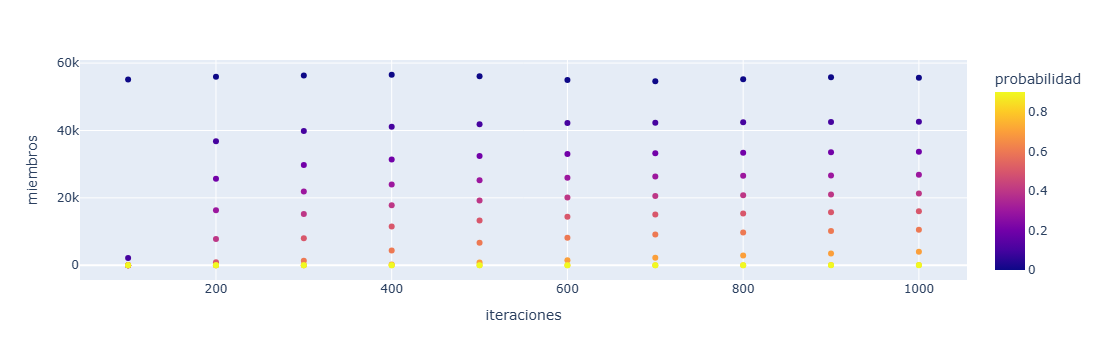

In [591]:
px.scatter(dataset, x='iteraciones', y='miembros', color='probabilidad')

In [592]:
dataf = df_agg[(df_agg['iteraciones_reales'] == 1000)]
dataf

,source_id,etapa,ConteoAgrupaciones,conteo_acumulado,etapa_aplicar,conteo_acumulado_aplicar,iteraciones_reales,probabilidad
9,3781052984777088,91,26,155,81,129,1000.0,0.129
26,9222153778284160,91,52,439,81,387,1000.0,0.387
36,11386989094573824,91,27,555,81,528,1000.0,0.528
44,12960562032443008,91,5,137,61,132,1000.0,0.132
48,16661724329748480,91,3,23,81,20,1000.0,0.020
...,...,...,...,...,...,...,...,...
556135,6914054089862745728,91,62,821,81,759,1000.0,0.759
556147,6915949373029453824,91,69,581,81,512,1000.0,0.512
556152,6916237724250150528,91,6,30,81,24,1000.0,0.024
556171,6917300367878632064,91,3,145,81,142,1000.0,0.142


In [593]:
data_send = dataf[['source_id','ConteoAgrupaciones','iteraciones_reales','probabilidad']].merge(df2[['source_id','pmra','pmdec','parallax','ra','dec','g','bp','rp']].rename(columns={'pmra':'pmra_norm','pmdec':'pmdec_norm','parallax':'parallax_norm','ra':'ra_norm','dec':'dec_norm','g':'g_norm','bp':'bp_norm','rp':'rp_norm'}), how='inner', on =['source_id'])

In [594]:
root_name = r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto"
df3 = pd.read_csv(root_name + r"\DatosTotales\gaia_parallax5.csv")
df3.head()

,source_id,ra,dec,parallax,pmra,pmdec,ruwe,phot_g_mean_mag,bp_rp,radial_velocity,ra_error,dec_error,pmra_error,pmdec_error,parallax_error,visibility_periods_used,phot_bp_mean_mag,phot_rp_mean_mag
0,4165071645134231936,264.949507,-9.526975,5.000000,19.845018,1.938150,1.195874,20.427282,2.499939,NaN,0.817550,0.660042,1.098323,0.832365,1.024663,17,21.479973,18.980034
1,4078365365086028416,280.297031,-23.435446,5.000000,-8.395027,-6.375871,1.261919,20.121367,1.466566,NaN,1.258058,1.219408,1.172961,1.113829,0.938785,10,20.634893,19.168327
2,4053338796833458304,264.140622,-34.822010,5.000001,0.610957,-1.728652,1.045413,20.159420,NaN,NaN,0.956572,0.711066,1.321774,0.923302,0.940663,11,NaN,NaN
3,6000271833111039744,229.040753,-44.673433,5.000001,6.288372,-5.347916,1.121972,20.677351,1.895269,NaN,1.709388,0.934137,2.239519,1.334990,2.069116,9,21.213799,19.318530
4,85457892001872000,42.273520,21.238497,5.000001,-45.116853,-41.222749,1.150009,18.027079,2.485622,NaN,0.154536,0.129362,0.215096,0.157081,0.168179,14,19.327946,16.842323


In [595]:
data_send = data_send.merge(df3[['source_id','pmra','pmdec','parallax','ra','dec','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','ra_error','dec_error','parallax_error','pmra_error','pmdec_error']], how='inner', on =['source_id'])

In [596]:
data_send['probabilidad'].describe()

count    55004.000000
mean         0.325025
std          0.233144
min          0.001000
25%          0.110000
50%          0.285000
75%          0.534000
max          0.841000
Name: probabilidad, dtype: float64

In [597]:
data_send.to_csv(root_name + f"\\notebooks\datos_resultados_union\datos_gaia_union_{version}.csv")

<>:1: SyntaxWarning:

invalid escape sequence '\d'

<>:1: SyntaxWarning:

invalid escape sequence '\d'

C:\Users\nicob\AppData\Local\Temp\ipykernel_13244\1550066170.py:1: SyntaxWarning:

invalid escape sequence '\d'



<Axes: xlabel='parallax', ylabel='Density'>

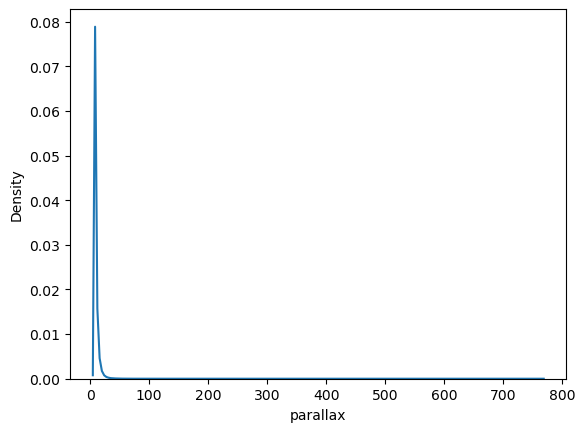

In [619]:
sns.kdeplot(data = df3, x = 'parallax')

(50.0, 1000.0)

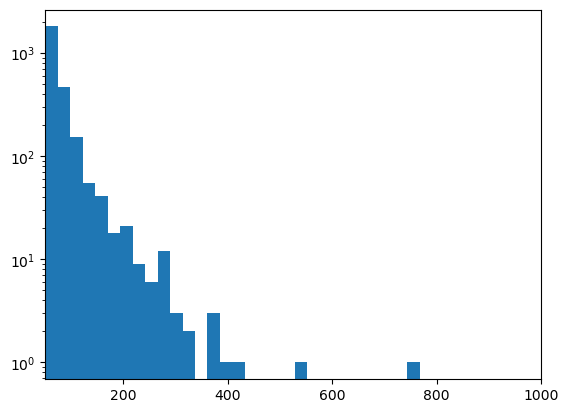

In [687]:
plt.hist(df3[df3['parallax']>50]['parallax'], bins=30)
plt.yscale('log')
plt.xlim(50, 1000)
# xticks = list(np.arange(5,10,0.2))
# plt.grid()
# plt.xticks(xticks, rotation = 60)

In [701]:
df3['bp_rp'] = df3['phot_bp_mean_mag'] -df3['phot_rp_mean_mag']
df3['g'] = df3['phot_g_mean_mag']
df3['Mg'] = df3['g'] + 5 - 5*np.log10(1000/df3['parallax'])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


5323


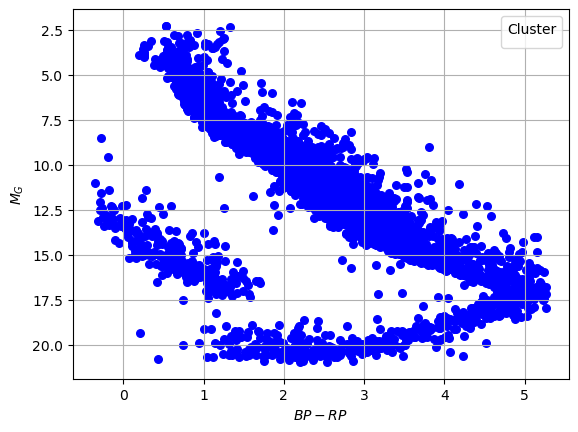

In [749]:
# plt.scatter(df3['bp_rp'],df3['Mg'], color='k', label='Noise')
min_parallax=40
print(len(df3[df3['parallax']>min_parallax]))
plt.scatter(df3[df3['parallax']>min_parallax]['bp_rp'], df3[df3['parallax']>min_parallax]['g'],
            color='b', s=30)
plt.xlabel(r'$BP - RP$')
plt.ylabel(r'$M_G$')
plt.legend(title='Cluster')
plt.gca().invert_yaxis()
plt.grid(True)
#     plt.savefig(f"ruta_imagenes_evolucion/diagramas_cm/diagrama_cluster_{cluster}.png")
plt.show()